In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import time
import os

In [3]:
def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

## 0. Define file path and load data

In [8]:
filebeginning = '20250502-1145-18_autosave_scan30_Hecho-alt-phased_with_two_point_tracking_3K_70mT_Bnv_sFC_NbSe2_S4_A-F17-26_' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\AttoDRY2200_Pi3_SPM\\'
filepath = path + filebeginning

with open(filepath+'qafm_array_raw.pickle', 'rb') as f:
    qafm_data = pickle.load(f)
with open(filepath+'pulsed_array_raw.pickle', 'rb') as f:
    pulsed_data = pickle.load(f)

## 1. Calculate corrected T2 signal with pulsed data

In [9]:
tip_osc_on_and_off = qafm_data['Height(Dac)_fw']['params']['Measure tip oscillation on and off']

data = pulsed_data['pulsed_fw']['data_delta']
t2_sig = data[:,:,1]
t2_ref = data[:,:,0]
t2_corr = t2_sig/t2_ref

if tip_osc_on_and_off:
    data_on = pulsed_data['pulsed_fw']['tip_osc_on']['data_delta']
    t2_sig_on = data_on[:,:,1]
    t2_ref_on = data_on[:,:,0]
    t2_corr_on = t2_sig_on/t2_ref_on

## 2. Plot all fit data
#### Corrected and uncorrected T2 signals

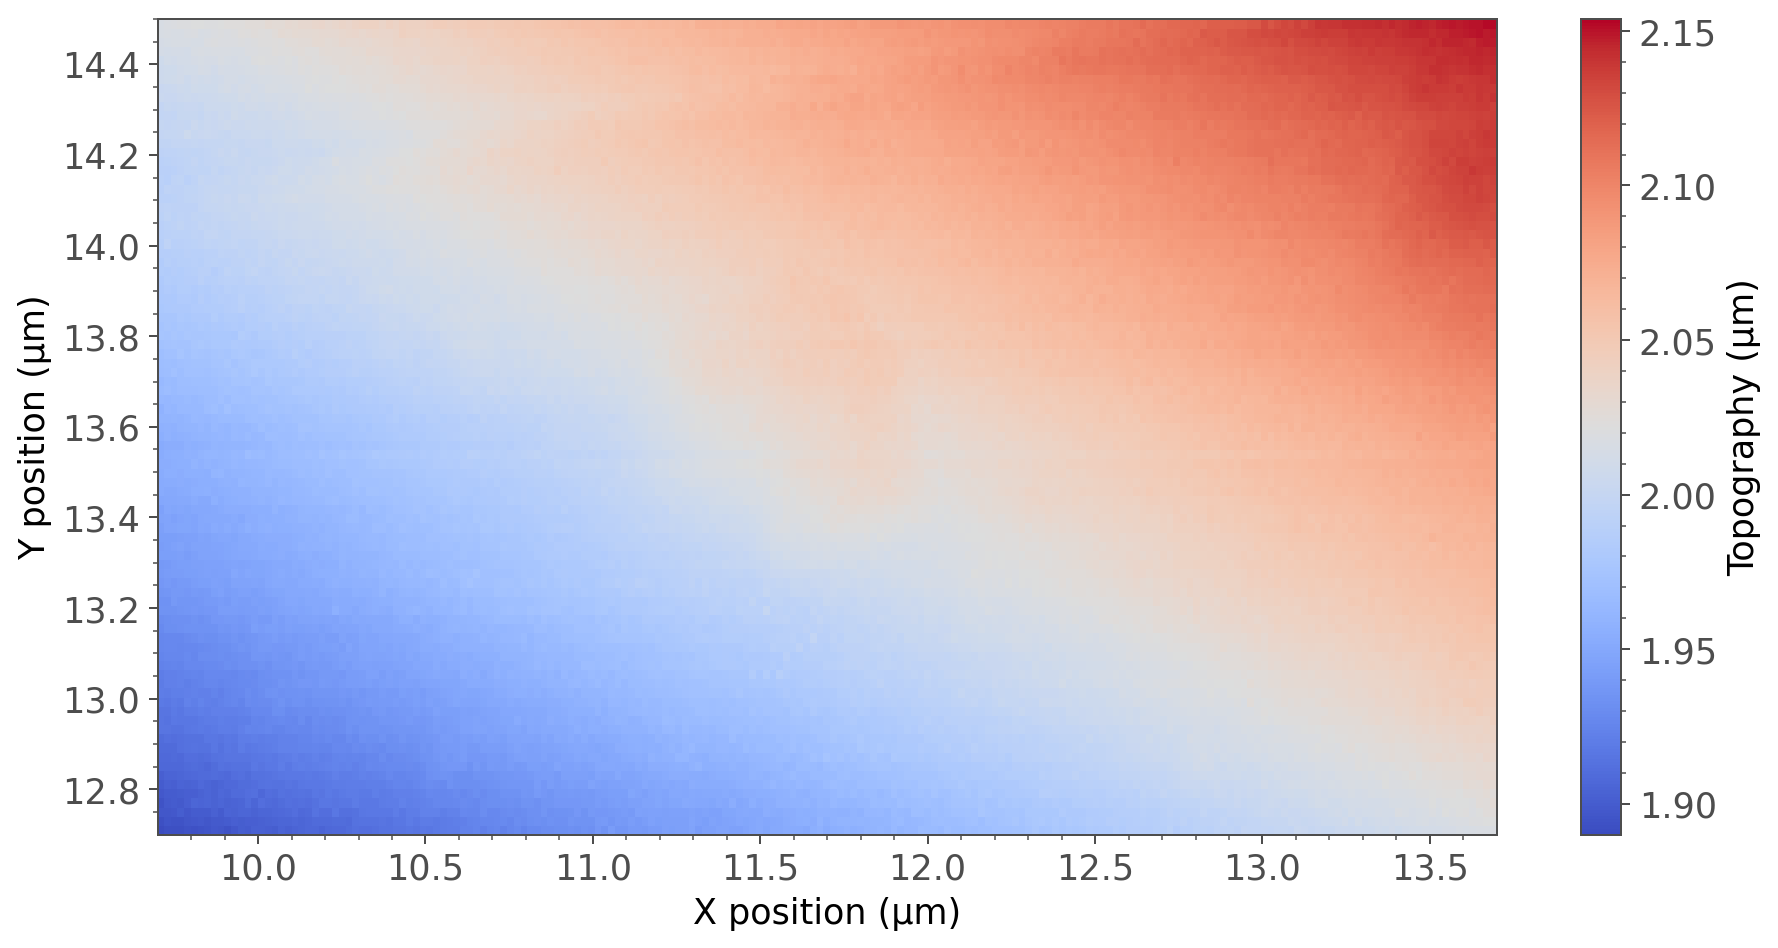

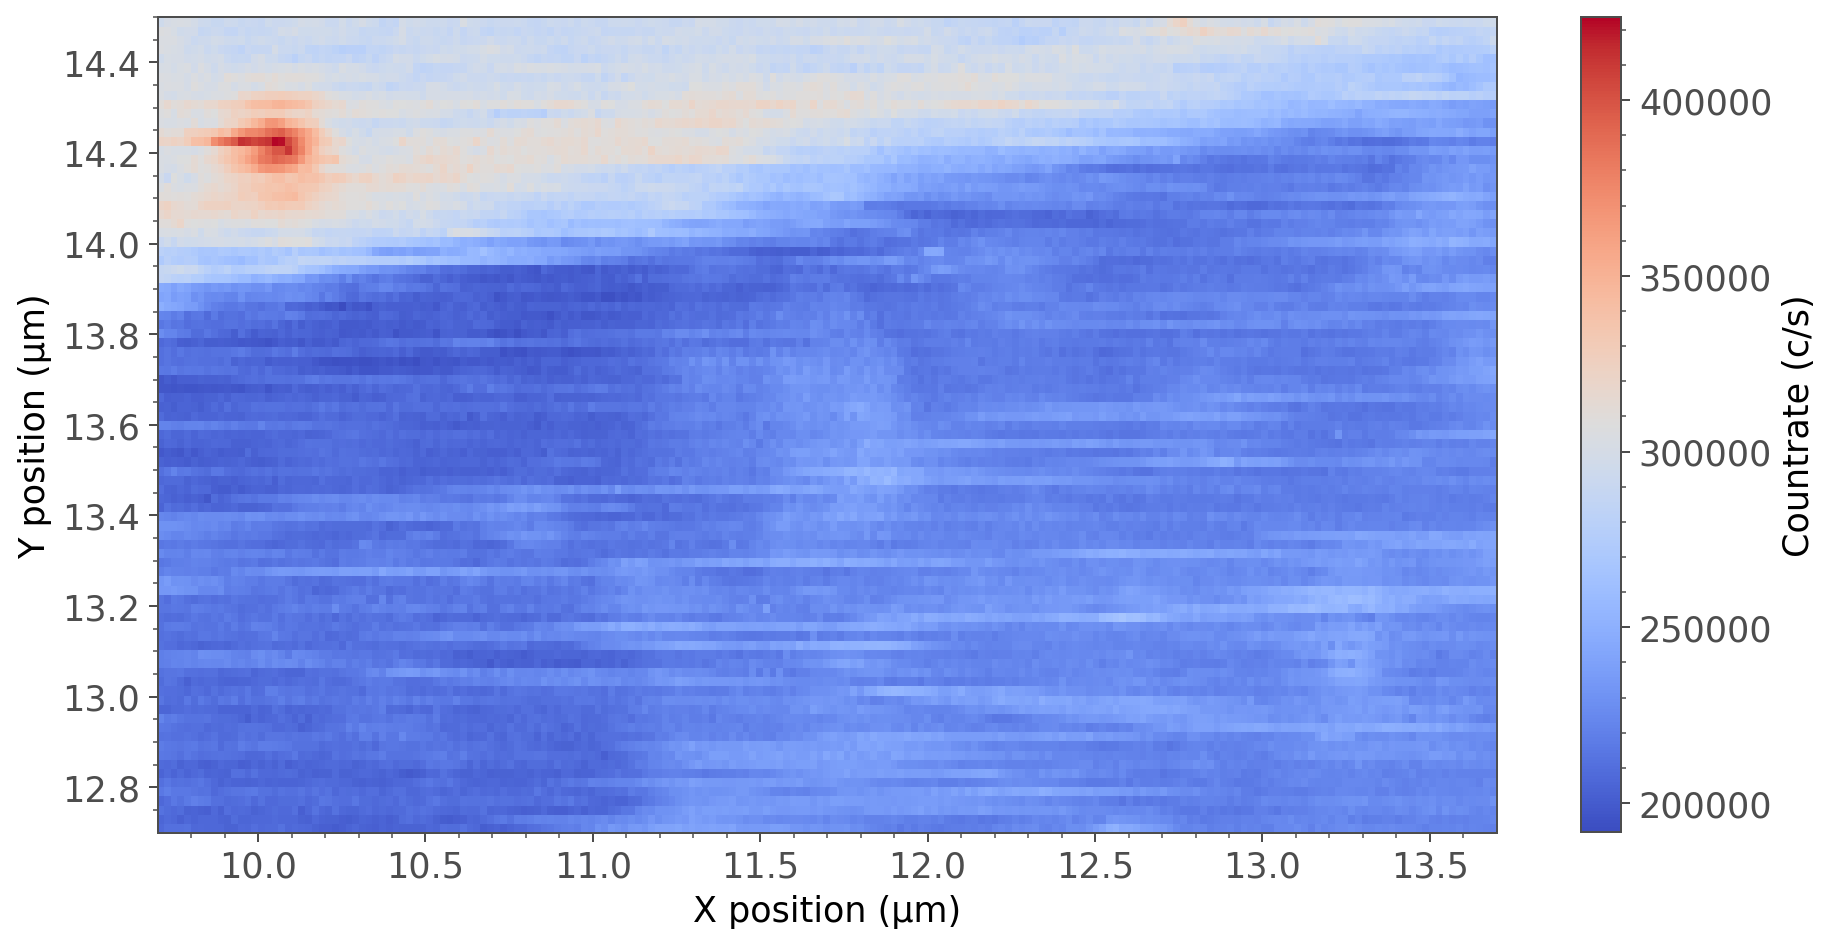

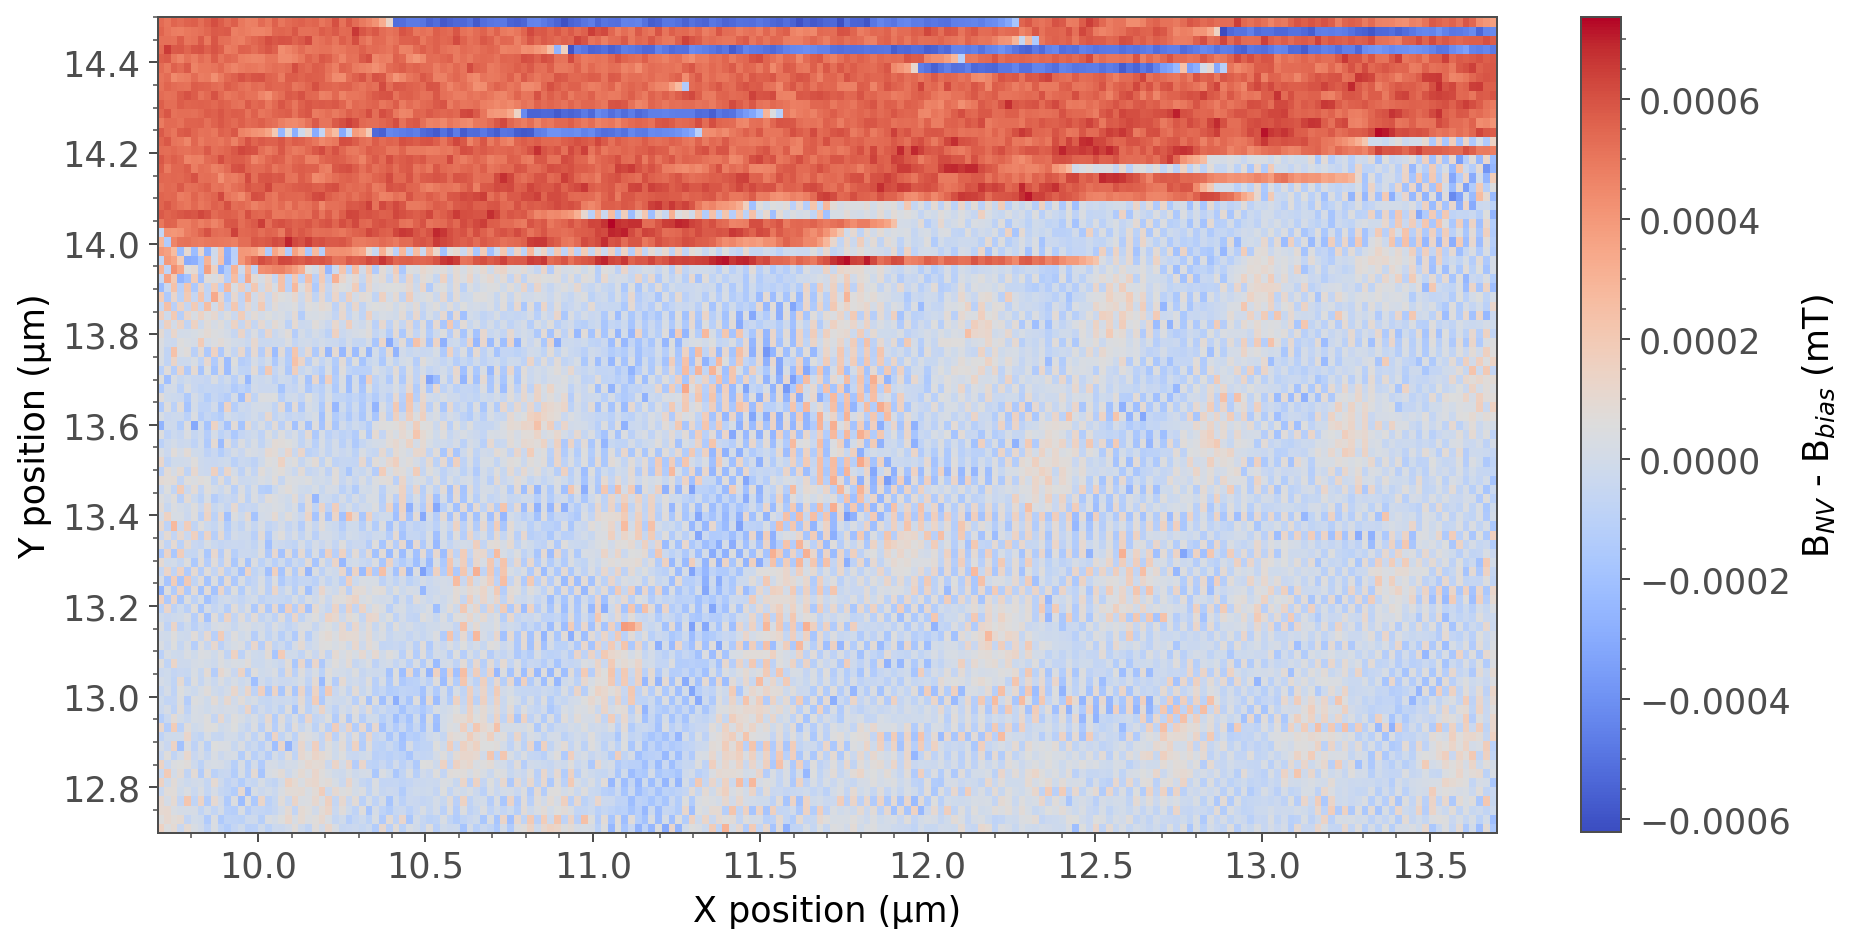

In [10]:
#Plot analysed Data from PODMR
x_gwy = qafm_data['Height(Dac)_fw']['coord0_arr']
y_gwy = qafm_data['Height(Dac)_fw']['coord1_arr']
x = x_gwy*10**6
y = y_gwy*10**6

#for gwyddion
dataobj = {}

## TOPO ##

low_centile = 0
high_centile = 100
data = qafm_data['Height(Dac)_fw']['data']*10**6
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Topography (\u03BCm)')
plt.show()
#for gwyddion
dataobj['Topography'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['Height(Dac)_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'm',
                            'nice_name': 'Topography'
    
                        }

## COUNTS ##

low_centile = 0
high_centile = 100
data = qafm_data['counts_fw']['data']
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'Countrate (c/s)')
plt.show()
#for gwyddion
dataobj['Fluorescence'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['counts_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'c/s',
                            'nice_name': 'Fluorescence'
    
                        }

## BFIELD CORR mT ##

low_centile = 0
high_centile = 100
data = qafm_data['b_field_fw']['data'] # b_field_bias is found earlier from OOC fit. In tesla
plt.pcolormesh(x,y,data,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data, low_centile), vmax = np.nanpercentile(data, high_centile))
plt.xlabel('X position (\u03BCm)')
plt.ylabel('Y position (\u03BCm)')
plt.colorbar(label = 'B$_{NV}$ - B$_{bias}$ (mT)')
plt.show()
#for gwyddion
dataobj['Stray Field'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                        
                            'si_units': 'T',
                            'nice_name': 'Stray Field: B_NV - B_bias'
    
                        }

## T2 signal a.u. ##
data = t2_sig
dataobj['T2_sig'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'a.u.',
                            'nice_name': 'T2_sig'
    
                        }

## T2 reference a.u. ##
data = t2_ref
dataobj['T2_ref'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'a.u.',
                            'nice_name': 'T2_ref'
    
                        }

## T2 CORR a.u. ##
data = t2_corr
dataobj['T2_corr'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':data,
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'a.u.',
                            'nice_name': 'T2_corr'
    
                        }

if tip_osc_on_and_off:
    ## T2 signal a.u. ##
    data = t2_sig_on
    dataobj['T2_sig_on'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                                                
                                'si_units': 'a.u.',
                                'nice_name': 'T2_sig_tip_osc_on'

                            }

    ## T2 reference a.u. ##
    data = t2_ref_on
    dataobj['T2_ref_on'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                                                
                                'si_units': 'a.u.',
                                'nice_name': 'T2_ref_tip_osc_on'

                            }

    ## T2 CORR a.u. ##
    data = t2_corr_on
    dataobj['T2_corr_on'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                                                
                                'si_units': 'a.u.',
                                'nice_name': 'T2_corr_tip_osc_on'

                            }

## 3. Save to new gwyddion file - data defined in previous cell

In [11]:
"""save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """
from logic import gwyfile as gwy
save_obj_to_gwyddion(dataobj=dataobj,filename=filepath+'QAFM_jupyter_fast_Hahn_echo_corrected.gwy')


## 4. Determine bias field if not already defined

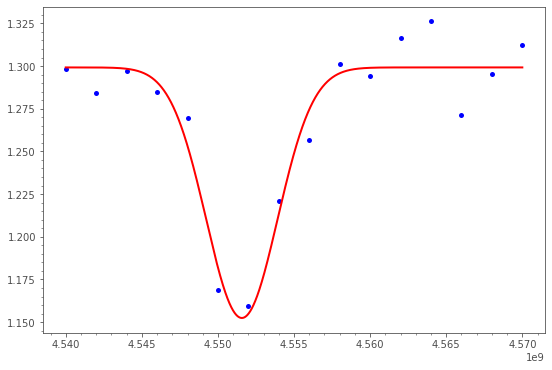

Bias field:  0.059698953042562584 T
FWHM:  5.519183457152336 MHz
Contrast:  11.297069346501532 %


In [5]:
#Analyse bias field
#Gathering data from dictonary
podrm_file = '20250131-1439-08_A-F17-26_NbSe2_S2_3K_8mT_OOP_OOC_ODMR_data_ch0_range0'+'.dat'

podmr_file_year = podrm_file[0:4]
podmr_file_month = podrm_file[4:6]
podmr_file_day = podrm_file[6:8]
podmr_path = 'G:\\Data\\Qudi_Data\\'+podmr_file_year+'\\'+podmr_file_month+'\\'+podmr_file_year+podmr_file_month+podmr_file_day+'\\PODMR\\'
podmr_filepath = podmr_path + podrm_file

data_raw = np.loadtxt(podmr_filepath).T
var_list,data = (data_raw[0],data_raw[1])

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

mode = 'gaussian_dip'
gslac = False
left = False

#Determine fit

if mode == 'double':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N15':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N14':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'gaussian_dip':
        fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
        lm,_ = fitlogic.make_gaussian_model()
    
else:    
    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
    lm,_ = fitlogic.make_lorentzian_model()

# print(fit.fit_report())
bias_res_freq = fit.params['center'].value

if gslac == True and left == True:
    b_field_bias = np.sqrt(abs(bias_res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field_bias = np.sqrt(abs(bias_res_freq - zero_field)**2 - e_field**2) / gyro_nv

#Plot Data an
plt.plot(var_list,data,'bo')

x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
plt.plot(x, lm.eval(fit.params, x=x),'r-')

plt.show()
fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
contrast_bias = fit.params['contrast'].value*-1
print('Bias field: ',b_field_bias,'T')
print("FWHM: ",fwhm_bias,'MHz')
print("Contrast: ",contrast_bias,'%')